In [3]:
import pandas as pd       
import numpy as np        
import matplotlib.pyplot as plt 
import seaborn as sns 
import pickle     

# Titanic Dataset 

In [4]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("Data loaded! Shape:", df.shape)

Data loaded! Shape: (891, 12)


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
missing_count = df.isnull().sum()
print("Missing values in each column:")
print(missing_count)


Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
#  percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
print("As percentage:")
print(missing_pct.round(1))


As percentage:
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            19.9
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.1
Embarked        0.2
dtype: float64


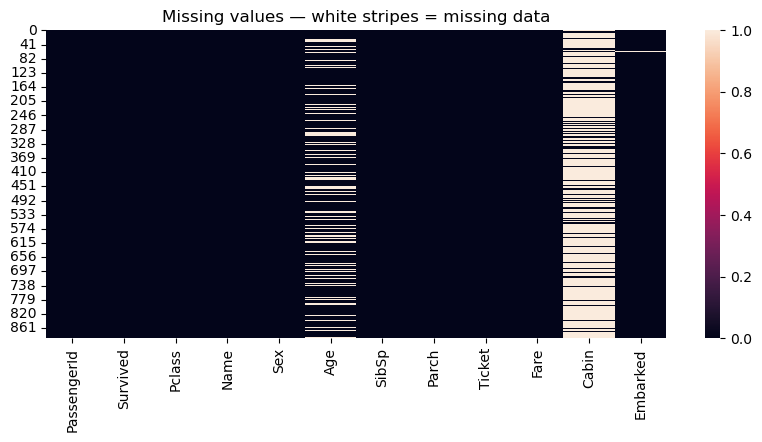

In [11]:
plt.figure(figsize=(10, 4))   # figure size: width=10, height=4 inches

sns.heatmap(df.isnull())

plt.title('Missing values — white stripes = missing data')
plt.show()


In [12]:
# AGE: 20% missing ---> fill with median age
# median reason ---> Because average is affected by very old/young passengers
df['Age'] = df['Age'].fillna(df['Age'].median())


# EMBARKED: only 2 missing — fill with most common num
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# CABIN: 77% missing — too much to fill, just remove 
df = df.drop(columns=['Cabin'])

In [13]:
print("Missing values after fixing:")
print(df.isnull().sum())


Missing values after fixing:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# EDA

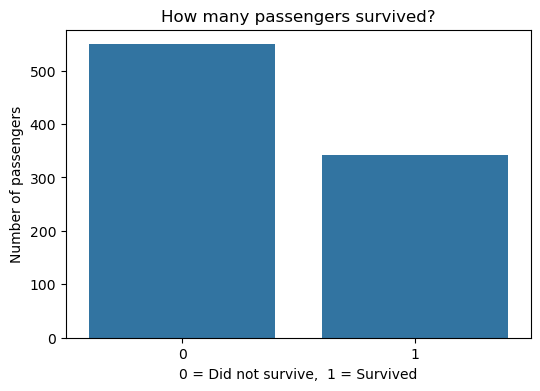

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [14]:
# countplot counts how many rows have each value

plt.figure(figsize=(6, 4))

sns.countplot( x='Survived',data=df)

plt.title('How many passengers survived?')
plt.xlabel('0 = Did not survive,  1 = Survived')
plt.ylabel('Number of passengers')
plt.show()

print(df['Survived'].value_counts())
print(df['Survived'].value_counts(normalize=True) * 100)  


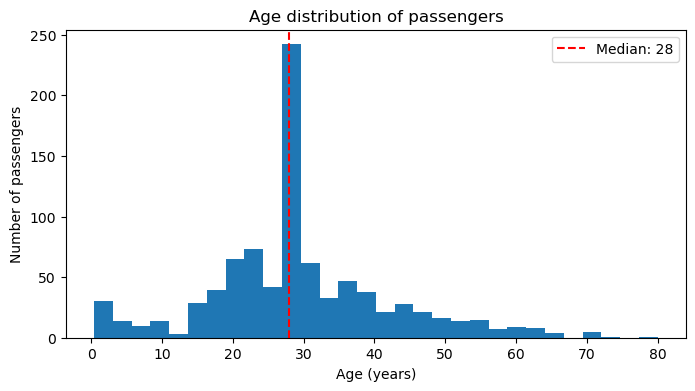

In [15]:
# histogram shows how values are spread across a range
# bins=30 means: divide the age range into 30 equal buckets

plt.figure(figsize=(8, 4))

plt.hist(df['Age'],bins=30)

plt.title('Age distribution of passengers')
plt.xlabel('Age (years)')
plt.ylabel('Number of passengers')

# to add a vertical line at the median age
plt.axvline(df['Age'].median(), color='red',linestyle='--', label=f"Median: {df['Age'].median():.0f}")
plt.legend()
plt.show()

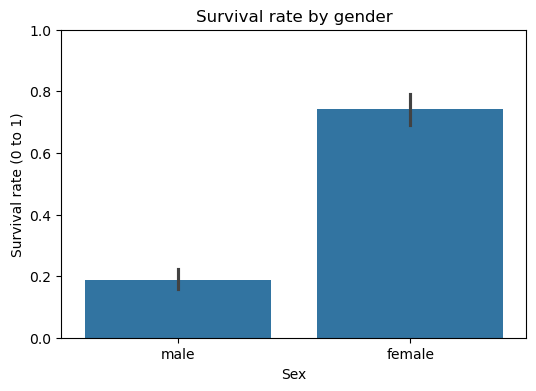

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [16]:
# barplot shows the AVERAGE of y for each category of x
# Since Survived is 0 or 1, the average = survival RATE

plt.figure(figsize=(6, 4))

sns.barplot(x='Sex', y='Survived',  data=df)

plt.title('Survival rate by gender')
plt.ylabel('Survival rate (0 to 1)')
plt.ylim(0, 1)   
plt.show()


print(df.groupby('Sex')['Survived'].mean() * 100)

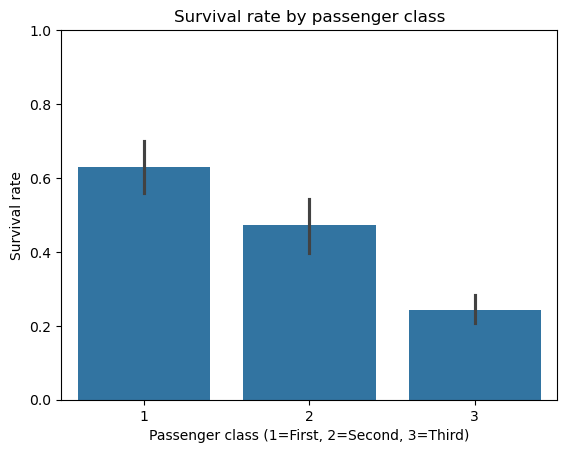

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [17]:

sns.barplot( x='Pclass', y='Survived', data=df)

plt.title('Survival rate by passenger class')
plt.xlabel('Passenger class (1=First, 2=Second, 3=Third)')
plt.ylabel('Survival rate')
plt.ylim(0, 1)
plt.show()

print(df.groupby('Pclass')['Survived'].mean() * 100)

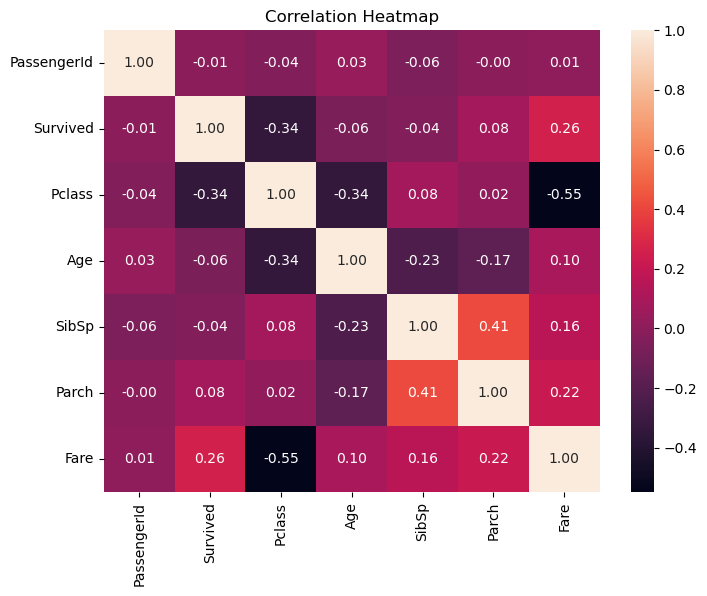

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr , annot = True , fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

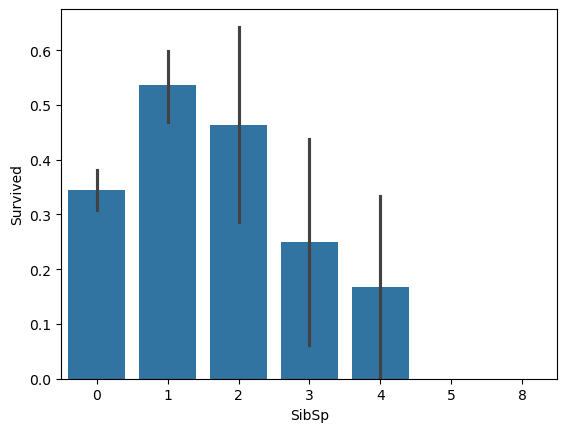

In [19]:
sns.barplot( x='SibSp',y='Survived',data=df)
plt.show()

In [20]:
# pivot_tble = for  Categorical analysis
# to know survival rate of each class and gender 

pivot = df.pivot_table(
    values='Survived',   # the number we want to calculate
    index='Pclass',      # rows of the table
    columns='Sex',       # columns of the table
    aggfunc='mean'       # mean = average = survival rate
)

print(pivot)  


Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


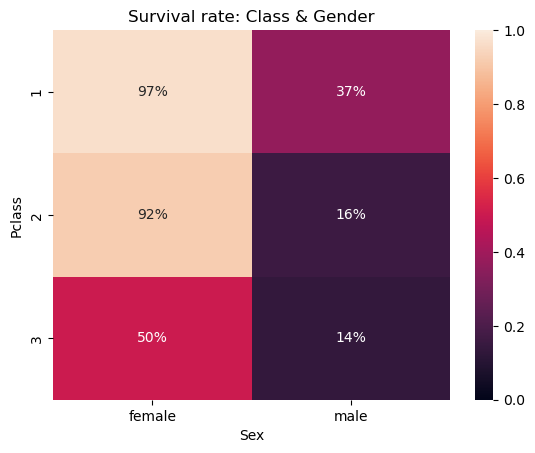

In [ ]:
# Pivot as a heatmap
sns.heatmap( pivot , annot=True , fmt='.0%', vmin=0 , vmax=1 )

plt.title('Survival rate: Class & Gender')
plt.show()

In [22]:
# Family size = Combine SibSp (siblings/spouse) + Parch (parents/children) + yourself

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
#                                            ^ +1 for yourself


# Create IsAlone column: 1 if traveling alone, 0 if with family
df['IsAlone'] = 0                           # start with 0 for everyone
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1  # set to 1 if alone

# Create age groups — easier to analyze than raw age numbers
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],          # the boundary points
    labels=['Child','Teen','YoungAdult','Adult','Senior']
)

print(df[['SibSp','Parch','FamilySize','IsAlone','AgeGroup']].head(5))


   SibSp  Parch  FamilySize  IsAlone    AgeGroup
0      1      0           2        0  YoungAdult
1      1      0           2        0       Adult
2      0      0           1        1  YoungAdult
3      1      0           2        0  YoungAdult
4      0      0           1        1  YoungAdult


In [23]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,YoungAdult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,YoungAdult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,YoungAdult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,YoungAdult


/tmp/ipykernel_186918/3554106482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x='FamilySize', y='Survived', data=df , palette='viridis')


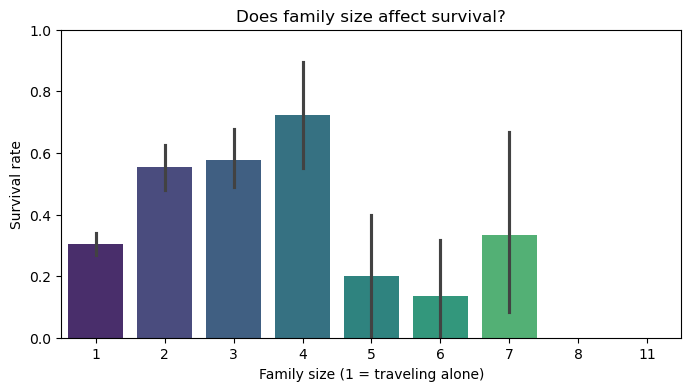

In [24]:
plt.figure(figsize=(8, 4))

sns.barplot( x='FamilySize', y='Survived', data=df , palette='viridis')

plt.title('Does family size affect survival?')
plt.xlabel('Family size (1 = traveling alone)')
plt.ylabel('Survival rate')
plt.ylim(0, 1)
plt.show()


"""


## Factors by above analysis :

**1 — Gender was the strongest survival factor**
Women had a 74% survival rate and  only 19% for men.
May be - women and childern are protected first or may happen that men helps women to save their life with children.

**2 — Passenger class revealed wealth inequality**
1st class: 63% survived | 2nd class: 47% | 3rd class: 24%
Passengers who paid more had better facilities for example first to sit on boat.

**3 — Children are also saved first**
Passengers under 12 had the highest survival rate.
Combined with gender, 1st class female children: nearly 100%.

**4 - Fare paid correlated with survival**
Survivors paid a median fare 2.5x higher than non-survivors.
Fare is a proxy for wealth and cabin location on the ship.

**5 — Traveling alone was riskier**
Solo travelers had ~30% survival vs ~55% for small families.
This may be because families helped each other to lifeboats.
"""


In [25]:
# All ML libraries:-
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


 Encode text columns to numbers

In [26]:
# to change text into number -> encoding 
le = LabelEncoder()

df['Sex_encoded']      = le.fit_transform(df['Sex'])       # female=0, male=1
df['Embarked_encoded'] = le.fit_transform(df['Embarked'])  # C=0, Q=1, S=2

print(df[['Sex','Sex_encoded','Embarked','Embarked_encoded']].drop_duplicates())

       Sex  Sex_encoded Embarked  Embarked_encoded
0     male            1        S                 2
1   female            0        C                 0
2   female            0        S                 2
5     male            1        Q                 1
22  female            0        Q                 1
26    male            1        C                 0


In [27]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,Sex_encoded,Embarked_encoded
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,YoungAdult,1,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Adult,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,YoungAdult,0,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,YoungAdult,0,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,YoungAdult,1,2


Choose features (X) and target (Y)

In [28]:
# X = input features ,  y = output(prediction)

features = ['Pclass','Sex_encoded','Age','Fare',
            'FamilySize','IsAlone','Embarked_encoded']

X = df[features]       # 7 input columns
y = df['Survived']     # 1 output column

print("X shape:", X.shape)   # (891, 7)
print("y shape:", y.shape)   # (891,)

X shape: (891, 7)
y shape: (891,)


In [29]:
X.head()

,Pclass,Sex_encoded,Age,Fare,FamilySize,IsAlone,Embarked_encoded
0,3,1,22.0,7.2500,2,0,2
1,1,0,38.0,71.2833,2,0,0
2,3,0,26.0,7.9250,1,1,2
3,1,0,35.0,53.1000,2,0,2
4,3,1,35.0,8.0500,1,1,2


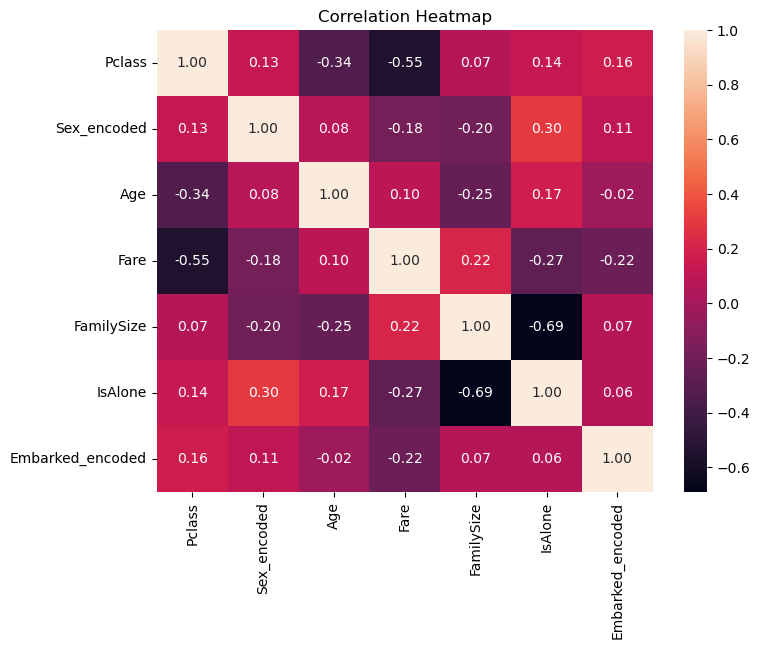

In [30]:
corr = X.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr , annot = True , fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [31]:
# 80% → model studies these passengers
# 20% → model is tested on these (never seen before)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", len(X_train), "passengers")
print("Test set    :", len(X_test),  "passengers")

Training set: 712 passengers
Test set    : 179 passengers


In [32]:
X_train.head()

,Pclass,Sex_encoded,Age,Fare,FamilySize,IsAlone,Embarked_encoded
331,1,1,45.5,28.5000,1,1,2
733,2,1,23.0,13.0000,1,1,2
382,3,1,32.0,7.9250,1,1,2
704,3,1,26.0,7.8542,2,0,2
813,3,0,6.0,31.2750,7,0,2


In [33]:
X_test.head()

,Pclass,Sex_encoded,Age,Fare,FamilySize,IsAlone,Embarked_encoded
709,3,1,28.0,15.2458,3,0,0
439,2,1,31.0,10.5000,1,1,2
840,3,1,20.0,7.9250,1,1,2
720,2,0,6.0,33.0000,2,0,2
39,3,0,14.0,11.2417,2,0,0


Scale features

In [34]:
# Age (0-80) and Fare (0-512) are very different ranges
# Scaling makes them equal so no column dominates the model

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn scale from train
X_test_scaled  = scaler.transform(X_test)        # apply same scale to test


# Logistic Regression + Regularization

In [35]:
# L2 regularization prevents overfitting (memorizing training data)
# C=1.0 is default. Small C = stronger regularization

lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)           # TRAINING

lr_pred = lr_model.predict(X_test_scaled)       # PREDICTING


lr_accuracy  = accuracy_score (y_test, lr_pred)   # Model 1
lr_precision = precision_score(y_test, lr_pred)
lr_recall    = recall_score   (y_test, lr_pred)
lr_f1        = f1_score       (y_test, lr_pred)

print(lr_accuracy)
print(lr_precision)
print(lr_recall)
print(lr_f1)

print()
print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")
print("Logistic Regression Precision:", round(lr_precision * 100, 2), "%")
print("Logistic Regression Recall:", round(lr_recall * 100, 2), "%")
print("Logistic Regression F1:", round(lr_f1 * 100, 2), "%")



0.7988826815642458
0.7794117647058824
0.7162162162162162
0.7464788732394366

Logistic Regression Accuracy: 79.89 %
Logistic Regression Precision: 77.94 %
Logistic Regression Recall: 71.62 %
Logistic Regression F1: 74.65 %


# Random Forest + Feature Importance

In [36]:
# 100 trees vote together — most accurate model usually

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)   # no scaling needed for Random Forest

rf_pred = rf_model.predict(X_test)


rf_accuracy  = accuracy_score (y_test, rf_pred)   # Model 1
rf_precision = precision_score(y_test, rf_pred)
rf_recall    = recall_score   (y_test, rf_pred)
rf_f1        = f1_score       (y_test, rf_pred)

print(rf_accuracy)
print(rf_precision)
print(rf_recall)
print(rf_f1)

print()
print(" Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
print(" Random Forest Precision:", round(rf_precision * 100, 2), "%")
print(" Random Forest Recall:", round(rf_recall * 100, 2), "%")
print(" Random Forest F1:", round(rf_f1 * 100, 2), "%")



0.8212290502793296
0.7916666666666666
0.7702702702702703
0.7808219178082192

 Random Forest Accuracy: 82.12 %
 Random Forest Precision: 79.17 %
 Random Forest Recall: 77.03 %
 Random Forest F1: 78.08 %


            Feature  Importance
0            Pclass    0.078191
1       Sex_encoded    0.270217
2               Age    0.264545
3              Fare    0.280412
4        FamilySize    0.059265
5           IsAlone    0.014800
6  Embarked_encoded    0.032570

         Feature  Importance
         IsAlone    0.014800
Embarked_encoded    0.032570
      FamilySize    0.059265
          Pclass    0.078191
             Age    0.264545
     Sex_encoded    0.270217
            Fare    0.280412


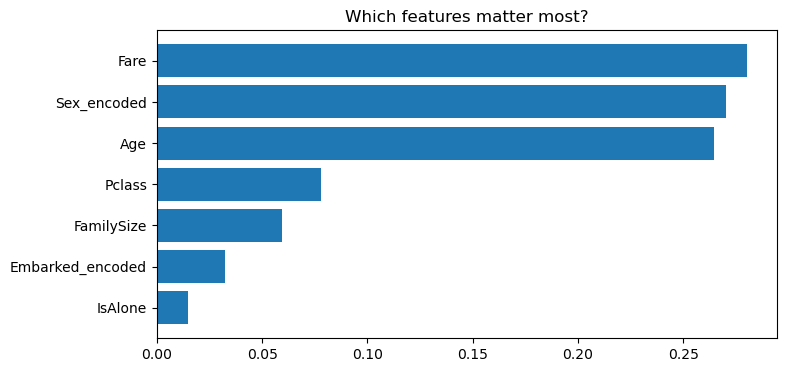

In [37]:
# Feature importance — which column mattered most?
imp_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
})

print(imp_df)
print()

importance_df = imp_df.sort_values('Importance')

print(importance_df.to_string(index=False))

# Chart
plt.figure(figsize=(8,4))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title('Which features matter most?')
plt.show()

# KNN Classifier

In [38]:
# Find 5 most similar passengers, majority vote decides prediction

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)   # KNN needs scaling

knn_pred = knn_model.predict(X_test_scaled)


knn_accuracy  = accuracy_score (y_test, rf_pred)   # Model 1
knn_precision = precision_score(y_test, rf_pred)
knn_recall    = recall_score   (y_test, rf_pred)
knn_f1        = f1_score       (y_test, rf_pred)

print(knn_accuracy)
print(knn_precision)
print(knn_recall)
print(knn_f1)

print()
print(" KNN Accuracy:", round(knn_accuracy * 100, 2), "%")
print(" KNN Precision:", round(knn_precision * 100, 2), "%")
print(" KNN Recall:", round(knn_recall * 100, 2), "%")
print(" KNN F1:", round(knn_f1 * 100, 2), "%")



0.8212290502793296
0.7916666666666666
0.7702702702702703
0.7808219178082192

 KNN Accuracy: 82.12 %
 KNN Precision: 79.17 %
 KNN Recall: 77.03 %
 KNN F1: 78.08 %


# Comparisons

In [39]:

re = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [round(lr_accuracy*100,2), round(rf_accuracy*100,2), round(knn_accuracy*100,2)]
})

result = re.sort_values('Accuracy', ascending=False)

print(result.to_string(index=False))


              Model  Accuracy
      Random Forest     82.12
                KNN     82.12
Logistic Regression     79.89


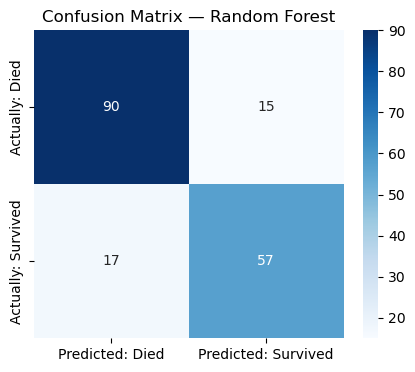

In [44]:
# Confusion matrix shows WHERE the model makes mistakes
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Died','Predicted: Survived'],
            yticklabels=['Actually: Died','Actually: Survived'])
plt.title('Confusion Matrix — Random Forest')
plt.show()


In [41]:
comparison_data = {
    'Model'    : ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy' : [lr_accuracy, rf_accuracy, knn_accuracy],
    'Precision': [lr_precision, rf_precision, knn_precision],
    'Recall' : [lr_recall , rf_recall , knn_recall]
}
comparison_df = pd.DataFrame(comparison_data)

In [42]:
comparison_df

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.798883,0.779412,0.716216
1,Random Forest,0.821229,0.791667,0.770270
2,KNN,0.821229,0.791667,0.770270


In [43]:
with open("model.pkl", "wb") as file:
    pickle.dump(rf_model, file)